In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.integrate import solve_ivp

import tinyDA as tda

# forward model evaluations

import pyvista as pv
import ufl
from dolfinx import fem, mesh, plot, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI


from ufl import dx, grad, inner

from helpers import interpolate_nonmatching, plot_function

In [21]:
#!pip install tinyda

def extract_parameters(list):
    output = []
    for element in list:
        output.append(element.parameters.tolist()[0])

    return(np.array(output))

## Forward Model Setup

In [22]:
class LinearElasticity:
    def __init__(self, solve_mesh: mesh, observation_mesh: mesh) -> None:
        self._observation_mesh = observation_mesh
        self._mesh = solve_mesh
        self._V = fem.functionspace(self._mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        self._V_observation = fem.functionspace(self._observation_mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        # boundary conditions
        facets_left = mesh.locate_entities_boundary(
            self._mesh,
            dim=(self._mesh.topology.dim - 1),
            marker=lambda x: np.isclose(x[0], 0.0),
        )
        dofs_left = fem.locate_dofs_topological(
            V=self._V, entity_dim=self._mesh.topology.dim - 1, entities=facets_left
        )
        bc_left = fem.dirichletbc(
            value=default_scalar_type((0,0)), dofs=dofs_left, V=self._V
        )


        # coefficient setup
        u = ufl.TrialFunction(self._V)
        v = ufl.TestFunction(self._V)
        f = fem.Constant(self._mesh, default_scalar_type((0,-0.1)))
        lam = 1
        mu = 1
        self._mu = fem.Constant(self._mesh, default_scalar_type(1))
        def epsilon(u):
            return 1/2 * (ufl.grad(u) + ufl.grad(u).T)
        def sigma(u):
            return lam * ufl.nabla_div(u) * ufl.Identity(len(u)) + self._mu * epsilon(u)

        

        # weak formulation
        a = inner(sigma(u), epsilon(v)) * dx
        L = inner(f, v) * dx  # + inner(g, v) * ds # only dirichlet

        self._problem = LinearProblem(
            a,
            L,
            bcs=[bc_left],
            petsc_options={"ksp_type": "cg", "pc_type": "gamg"},
            petsc_options_prefix="lp",
        )

        # performance optimization
        self._cells_V_to = np.arange(
            self._V_observation.mesh.topology.index_map(
                self._V_observation.mesh.topology.dim
            ).size_local,
            dtype=np.int32,
        )
        self._interpolation_data = fem.create_interpolation_data(
            self._V_observation, self._V, self._cells_V_to
        )
        
    def _evaluate(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the PDE solution operator S."""
        self._mu.value = state
        sol = self._problem.solve()
        return sol

    def __call__(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the observation operator"""
        pde_sol = self._evaluate(state)
        observed = interpolate_nonmatching(
            self._V_observation,
            self._V,
            pde_sol,
            self._interpolation_data,
            self._cells_V_to,
        )
        return observed.x.array, 0 # placeholder for qoi

    @property
    def gdim(self):
        return self._mesh.geometry.dim

    @property
    def ndofs(self):
        return self._V.dofmap.index_map.size_global

In [23]:
# UNIFORM REFINEMENT

_msh = mesh.create_unit_square(MPI.COMM_WORLD, 20, 20)
_msh.topology.create_entities(1)

_msh2 = mesh.refine(_msh)[0]

_obs_msh = mesh.create_unit_square(MPI.COMM_WORLD, 10, 10)

In [24]:
# MODEL HIERARCHY

model1 = LinearElasticity(_msh, _obs_msh)
model2 = LinearElasticity(_msh2, _obs_msh)

## Inverse Problem Setup

In [25]:
# set true parameter(s)

mu = 1

true_parameters = np.array([mu]) # no log

x_true = model2(true_parameters)[0] # true displacement
x_true.shape

# generate data

sigma = 0.01

noise = np.random.normal(scale=sigma, size=(x_true.shape[0]))
data = x_true#+noise

In [26]:
plot_function(model2._V_observation, data)

Widget(value='<iframe src="http://localhost:52392/index.html?ui=P_0x3246f2cc0_1&reconnect=auto" class="pyvista…

In [27]:
#uniform_prior = stats.uniform(loc=np.log(0.5), scale=bnp.log(1.5)-np.log(0.5))
uniform_prior = stats.uniform(loc=0, scale=2)

In [28]:
cov_likelihood = sigma**2*np.eye(data.size)

loglike = tda.GaussianLogLike(data, cov_likelihood)

In [29]:
my_posterior = tda.Posterior(uniform_prior, loglike, model2)

In [30]:
MAP = tda.get_MAP(my_posterior)
print(MAP)


[0.99999999]


In [31]:
MAP

array([0.99999999])

In [32]:
# random walk Metropolis
#rwmh_cov = np.eye(1)
#rmwh_scaling = 0.1
#rwmh_adaptive = True
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# Adaptive Metropolis
#am_cov = np.eye(true_parameters.size)
#am_t0 = 100
#am_sd = None
#am_epsilon = 1e-6
#am_adaptive = True
#my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

dream_m0 = 1000
dream_delta = 1
dream_Z_method = 'lhs'
dream_adaptive = True
my_proposal = tda.DREAMZ(M0=dream_m0, delta=dream_delta, Z_method=dream_Z_method, adaptive=dream_adaptive)

In [33]:
my_chain = tda.sample(my_posterior, my_proposal, iterations=5000, n_chains=1, initial_parameters=MAP)

Sampling chain 1/1


Running chain, α = 0.31: 100%|██████████| 5000/5000 [00:53<00:00, 93.43it/s] 


In [34]:
parameters = extract_parameters(my_chain['chain_0'])

In [17]:
np.min(parameters)

0.9726961452358842

(array([ 0.44770808,  2.48274482, 11.4776072 , 29.71153638, 42.49156709,
        52.42254638, 40.45653036, 17.62341815,  5.53529993,  0.89541616]),
 array([0.9742988 , 0.97921173, 0.98412466, 0.9890376 , 0.99395053,
        0.99886346, 1.0037764 , 1.00868933, 1.01360226, 1.0185152 ,
        1.02342813]),
 <BarContainer object of 10 artists>)

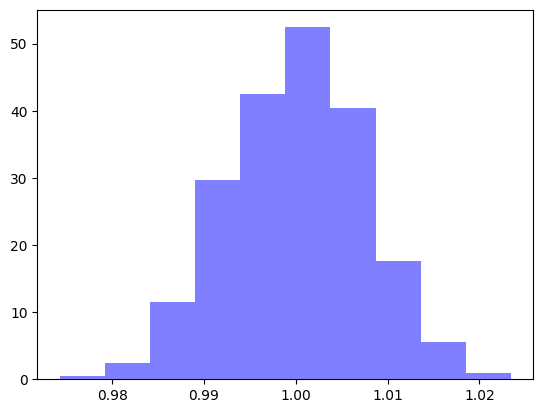

In [280]:
plt.hist(extract_parameters(my_chain['chain_0']), density=True, alpha=0.5, color="blue")

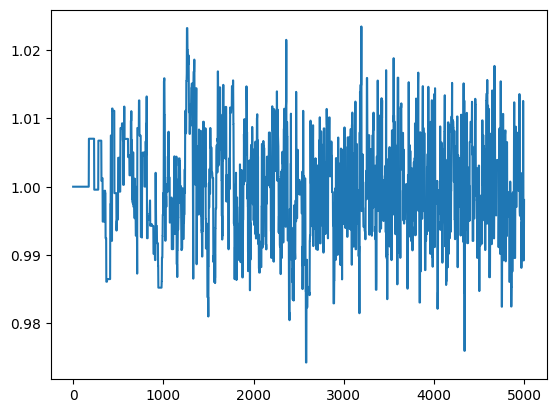

In [281]:
plt.plot(extract_parameters(my_chain['chain_0']))

In [270]:
model2(1)[0]-data

array([-1.75738719e-09,  5.46621193e-10, -1.54089470e-09,  1.66368491e-09,
       -3.43845204e-09,  1.77185897e-09, -3.17692336e-09,  6.69730105e-10,
       -2.53248075e-09,  5.13097315e-10, -4.08383247e-09, -1.01307018e-11,
       -2.68492410e-09,  7.47274714e-10, -5.28628082e-09,  3.91793070e-10,
       -1.51511624e-09,  1.89880081e-09, -4.07068518e-09, -9.76836168e-10,
       -2.14472586e-09,  1.88041843e-09, -4.73761155e-09,  2.04584844e-09,
       -4.30883824e-09,  4.85219781e-10, -4.40808182e-10,  1.93742308e-09,
       -3.64646929e-09, -2.19131913e-09, -2.14449555e-09,  8.91667434e-10,
       -5.01032833e-09,  3.05250422e-09, -4.78393944e-09,  1.56303351e-09,
       -4.17550385e-09,  4.60411820e-10,  7.72470907e-10, -3.02313143e-09,
       -2.95855046e-09, -2.93859845e-09, -4.70441543e-09, -2.72297725e-09,
       -4.55416504e-09,  3.95981969e-10, -5.49823828e-09,  1.79716195e-09,
       -4.52782493e-09,  9.53794932e-10, -2.79295396e-09, -4.69440903e-10,
       -6.81899349e-10, -

In [271]:
data

array([-6.79262393e-02, -1.96987412e-01, -6.78554745e-02, -2.12379496e-01,
       -5.26621400e-02, -2.11955368e-01, -5.22875859e-02, -1.96690622e-01,
       -6.80757271e-02, -1.80649990e-01, -3.81036759e-02, -2.10808599e-01,
       -5.16751892e-02, -1.80205496e-01, -3.75466050e-02, -1.95957324e-01,
       -6.77902363e-02, -1.62871620e-01, -2.45953119e-02, -2.09463116e-01,
       -5.04590329e-02, -1.62050452e-01, -3.67757385e-02, -1.79328930e-01,
       -2.40839821e-02, -1.95150872e-01, -6.65212401e-02, -1.43598307e-01,
       -1.20290424e-02, -2.08432953e-01, -4.83088162e-02, -1.42189182e-01,
       -3.54186136e-02, -1.60796498e-01, -2.34447857e-02, -1.78462411e-01,
       -1.17298158e-02, -1.94546119e-01, -6.37767872e-02, -1.22984125e-01,
       -4.13861829e-07, -2.08051892e-01, -4.48886166e-02, -1.20785503e-01,
       -3.32471548e-02, -1.40418148e-01, -2.23688585e-02, -1.59629376e-01,
       -1.13753310e-02, -1.77853911e-01,  5.90471204e-08, -1.94323112e-01,
       -5.90865248e-02, -

In [250]:
loglike.loglike(model1(1)[0])

-0.00020794965220364154

In [251]:
loglike.loglike(model2(1)[0])

-5.528993999035067e-16

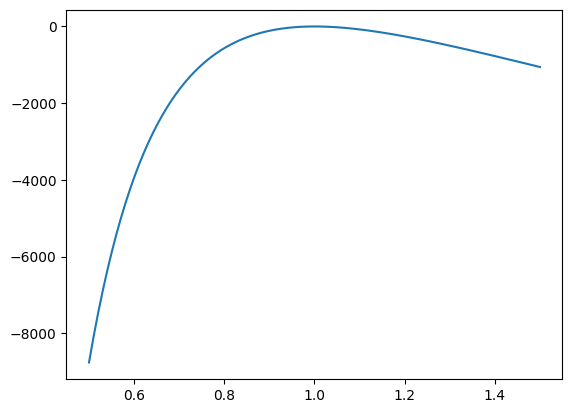

In [272]:
xs = np.linspace(0.5, 1.5, 100)
likes = np.min([loglike.loglike(model2(x)[0]) for x in xs])
plt.plot(xs, [loglike.loglike(model2(x)[0]) for x in xs])

In [253]:
loglike.data - model2(1)[0]

array([ 1.75738719e-09, -5.46621193e-10,  1.54089470e-09, -1.66368491e-09,
        3.43845204e-09, -1.77185897e-09,  3.17692336e-09, -6.69730105e-10,
        2.53248075e-09, -5.13097315e-10,  4.08383247e-09,  1.01307018e-11,
        2.68492410e-09, -7.47274714e-10,  5.28628082e-09, -3.91793070e-10,
        1.51511624e-09, -1.89880081e-09,  4.07068518e-09,  9.76836168e-10,
        2.14472586e-09, -1.88041843e-09,  4.73761155e-09, -2.04584844e-09,
        4.30883824e-09, -4.85219781e-10,  4.40808182e-10, -1.93742308e-09,
        3.64646929e-09,  2.19131913e-09,  2.14449555e-09, -8.91667434e-10,
        5.01032833e-09, -3.05250422e-09,  4.78393944e-09, -1.56303351e-09,
        4.17550385e-09, -4.60411820e-10, -7.72470907e-10,  3.02313143e-09,
        2.95855046e-09,  2.93859845e-09,  4.70441543e-09,  2.72297725e-09,
        4.55416504e-09, -3.95981969e-10,  5.49823828e-09, -1.79716195e-09,
        4.52782493e-09, -9.53794932e-10,  2.79295396e-09,  4.69440903e-10,
        6.81899349e-10,  

In [ ]:
np.linalg.eig(loglike.cov_inverse)

EigResult(eigenvalues=array([ -0.41492054+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+7.03401421e-14j,
       101.01010101-7.03401421e-14j, 101.01010101+0.00000000e+00j,
       101.01010101+1.34956365e-13j, 101.01010101-1.34956365e-13j,
       101.01010101+4.71320730e-14j, 101.01010101-4.71320730e-14j,
       101.01010101+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+3.10735538e-14j,
       101.01010101-3.10735538e-14j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101.01010101+0.00000000e+00j,
       101.01010101+0.00000000e+00j, 101

In [ ]:
idata = tda.to_inference_data(my_chain, burnin=0)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

: 